# Locus.ai — Baseline vs Fine-tuned Benchmark
**Model:** Qwen/Qwen3.5-2B (baseline) vs `merged_model/` (fine-tuned, merged 16-bit)

Benchmarks:
1. JSON Parse Rate
2. Primary Location Exact-Match Accuracy
3. ROUGE-L on full response
4. Latency (tokens/sec)
5. Summary bar chart

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────────
# For Apple Silicon (Metal GPU):
# CMAKE_ARGS="-DGGML_METAL=on" pip install llama-cpp-python
# For CUDA:
# CMAKE_ARGS="-DGGML_CUDA=on" pip install llama-cpp-python
# !pip install rouge-score

In [2]:
# ── Shared imports ─────────────────────────────────────────────────────────────
import json, re, time, gc
import numpy as np
from llama_cpp import Llama

MAX_SEQ_LENGTH = 2048
MAX_NEW_TOKENS = 512
NUM_SAMPLES    = 100   # set to None to run the full test set
TEST_FILE      = "data/splits/test.jsonl"
FT_GGUF_PATH   = "locus.ai-BF16.gguf"

## 1 — Load Models

In [3]:
# ── Load both models ──────────────────────────────────────────────────────────
print("Loading BASE model...")
base_llm = Llama.from_pretrained(
    repo_id      = "unsloth/Qwen3.5-2B-GGUF",
    filename     = "Qwen3.5-2B-BF16.gguf",
    n_gpu_layers = -1,
    n_ctx        = MAX_SEQ_LENGTH,
    verbose      = False,
)
print("Base model ready.")

print("Loading FINE-TUNED model...")
ft_llm = Llama(
    model_path   = FT_GGUF_PATH,
    n_gpu_layers = -1,
    n_ctx        = MAX_SEQ_LENGTH,
    verbose      = False,
)
print("Fine-tuned model ready.")

Loading BASE model...


/Users/sameerkashyap/code/locus.ai/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/sameerkashyap/code/locus.ai/.venv/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


llama_context: n_ctx_seq (2048) < n_ctx_train (262144) -- the full capacity of the model will not be utilized


Base model ready.
Loading FINE-TUNED model...


llama_context: n_ctx_seq (2048) < n_ctx_train (262144) -- the full capacity of the model will not be utilized


Fine-tuned model ready.


In [4]:
# ── Inference helper (llama-cpp-python) ───────────────────────────────────────
def run_inference_gguf(llm, examples, max_new=MAX_NEW_TOKENS):
    """Greedy inference via llama-cpp-python; returns (predictions, tokens_per_sec list)."""
    preds, tps_list = [], []
    for ex in examples:
        # Explicitly reset before each call so the prefix-match cache reuse
        # optimization is skipped — required for Qwen3.5's hybrid SSM/Mamba
        # architecture where recurrent states cannot be partially reused.
        llm.reset()

        t0  = time.perf_counter()
        out = llm.create_chat_completion(
            messages    = [{"role": "user", "content": ex["instruction"]}],
            max_tokens  = max_new,
            temperature = 0.0,
        )
        elapsed = time.perf_counter() - t0

        text  = out["choices"][0]["message"]["content"].strip()
        n_gen = out["usage"]["completion_tokens"]
        tps_list.append(n_gen / elapsed if elapsed > 0 else 0)
        preds.append(text)

    return preds, tps_list

print("Inference helper defined.")

Inference helper defined.


## 2 — Test Data & Helpers

In [5]:
# ── Load test examples ────────────────────────────────────────────────────────
def load_test(path, n=None):
    rows = []
    with open(path) as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows[:n] if n else rows

test_examples = load_test(TEST_FILE, NUM_SAMPLES)
refs          = [ex["response"] for ex in test_examples]
print(f"Loaded {len(test_examples)} test examples.")

Loaded 100 test examples.


In [6]:
# ── Metric helpers ────────────────────────────────────────────────────────────
def extract_primary(text):
    """Parse primary_location from JSON response, with regex fallback."""
    try:
        obj = json.loads(text)
        return str(obj.get("primary_location", "")).strip().lower()
    except Exception:
        m = re.search(r'"primary_location"\s*:\s*"([^"]+)"', text)
        return m.group(1).strip().lower() if m else ""


def rouge_l_f1(pred, ref):
    """Token-level ROUGE-L F1."""
    p_tok, r_tok = pred.split(), ref.split()
    if not p_tok or not r_tok:
        return 0.0
    m, n = len(p_tok), len(r_tok)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            dp[i][j] = dp[i-1][j-1] + 1 if p_tok[i-1] == r_tok[j-1] else max(dp[i-1][j], dp[i][j-1])
    lcs  = dp[m][n]
    prec = lcs / m
    rec  = lcs / n
    return 2 * prec * rec / (prec + rec) if prec + rec else 0.0


def compute_metrics(preds, refs, tps_list):
    json_ok, loc_exact, rl_scores = [], [], []
    for pred, ref in zip(preds, refs):
        try:
            json.loads(pred)
            json_ok.append(1)
        except Exception:
            json_ok.append(0)
        loc_exact.append(int(extract_primary(pred) == extract_primary(ref)))
        rl_scores.append(rouge_l_f1(pred, ref))
    return {
        "json_parse_rate (%)":    np.mean(json_ok)    * 100,
        "location_accuracy (%)":  np.mean(loc_exact)  * 100,
        "rouge_l (%)":            np.mean(rl_scores)  * 100,
        "avg_tokens_per_sec":     np.mean(tps_list),
    }

print("Helpers defined.")

Helpers defined.


## 3 — Run Inference

In [7]:
# ── Baseline inference ────────────────────────────────────────────────────────
print(f"Running baseline inference on {len(test_examples)} examples...")
baseline_preds, baseline_tps = run_inference_gguf(base_llm, test_examples)
print(f"Done. Avg speed: {np.mean(baseline_tps):.1f} tok/s")

Running baseline inference on 100 examples...


Done. Avg speed: 22.0 tok/s


In [8]:
# ── Fine-tuned inference ──────────────────────────────────────────────────────
print(f"Running fine-tuned inference on {len(test_examples)} examples...")
ft_preds, ft_tps = run_inference_gguf(ft_llm, test_examples)
print(f"Done. Avg speed: {np.mean(ft_tps):.1f} tok/s")

Running fine-tuned inference on 100 examples...


Done. Avg speed: 17.8 tok/s


## 4 — Benchmark 1: JSON Parse Rate
Measures what fraction of responses are valid JSON — critical since downstream code parses the output.

Baseline  JSON Parse Rate: 0.0%
Fine-tuned JSON Parse Rate: 0.0%
Delta: +0.0pp


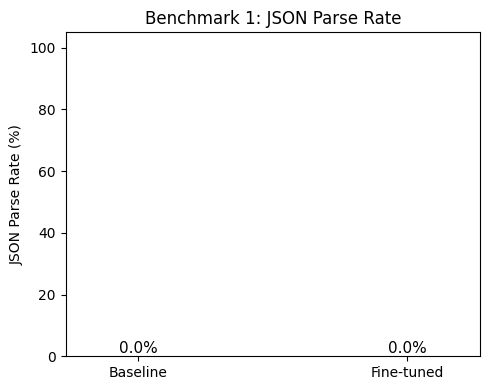

In [9]:
import matplotlib.pyplot as plt

def json_parse_rate(preds):
    results = []
    for pred in preds:
        try:
            json.loads(pred)
            results.append(1)
        except Exception:
            results.append(0)
    return results

base_json = json_parse_rate(baseline_preds)
ft_json   = json_parse_rate(ft_preds)

base_rate = np.mean(base_json) * 100
ft_rate   = np.mean(ft_json)   * 100

print(f"Baseline  JSON Parse Rate: {base_rate:.1f}%")
print(f"Fine-tuned JSON Parse Rate: {ft_rate:.1f}%")
print(f"Delta: {ft_rate - base_rate:+.1f}pp")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Baseline", "Fine-tuned"], [base_rate, ft_rate],
       color=["salmon", "steelblue"], width=0.4)
ax.set_ylabel("JSON Parse Rate (%)")
ax.set_title("Benchmark 1: JSON Parse Rate")
ax.set_ylim(0, 105)
for i, v in enumerate([base_rate, ft_rate]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("outputs_qwen35/bench_json_parse.png", dpi=150)
plt.show()

## 5 — Benchmark 2: Primary Location Exact-Match Accuracy
Extracts the `primary_location` field and checks exact string match against the ground-truth.

Baseline   Location Accuracy: 26.0%
Fine-tuned Location Accuracy: 26.0%
Delta: +0.0pp

Per-location accuracy (fine-tuned, top-10 by count):
                                  26/26   (100%)
  nucleoplasm                      0/20   (0%)
  mitochondria                     0/5    (0%)
  cytosol                          0/4    (0%)
  nucleoplasm;cytosol              0/4    (0%)
  nuclear bodies;nucleoplasm       0/2    (0%)
  nuclear bodies                   0/2    (0%)
  plasma membrane                  0/2    (0%)
  nucleoplasm;vesicles             0/2    (0%)
  nucleoplasm;nuclear bodies       0/2    (0%)


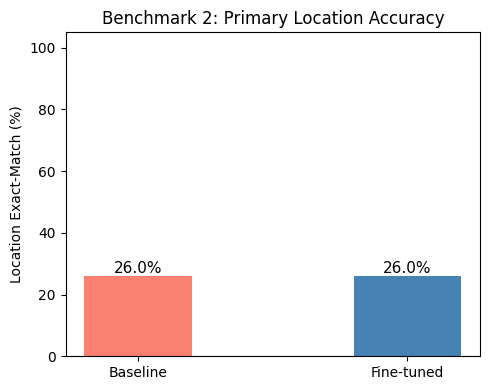

In [10]:
base_loc_hits = [int(extract_primary(p) == extract_primary(r)) for p, r in zip(baseline_preds, refs)]
ft_loc_hits   = [int(extract_primary(p) == extract_primary(r)) for p, r in zip(ft_preds,       refs)]

base_loc_acc = np.mean(base_loc_hits) * 100
ft_loc_acc   = np.mean(ft_loc_hits)   * 100

print(f"Baseline   Location Accuracy: {base_loc_acc:.1f}%")
print(f"Fine-tuned Location Accuracy: {ft_loc_acc:.1f}%")
print(f"Delta: {ft_loc_acc - base_loc_acc:+.1f}pp")

# ── Per-location breakdown (fine-tuned) ──
from collections import defaultdict
loc_correct = defaultdict(int)
loc_total   = defaultdict(int)
for p, r, hit in zip(ft_preds, refs, ft_loc_hits):
    true_loc = extract_primary(r)
    loc_total[true_loc]   += 1
    loc_correct[true_loc] += hit

print("\nPer-location accuracy (fine-tuned, top-10 by count):")
sorted_locs = sorted(loc_total.items(), key=lambda x: -x[1])[:10]
for loc, total in sorted_locs:
    acc = loc_correct[loc] / total * 100
    print(f"  {loc:<30} {loc_correct[loc]:>3}/{total:<3}  ({acc:.0f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Baseline", "Fine-tuned"], [base_loc_acc, ft_loc_acc],
       color=["salmon", "steelblue"], width=0.4)
ax.set_ylabel("Location Exact-Match (%)")
ax.set_title("Benchmark 2: Primary Location Accuracy")
ax.set_ylim(0, 105)
for i, v in enumerate([base_loc_acc, ft_loc_acc]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("outputs_qwen35/bench_location_acc.png", dpi=150)
plt.show()

## 6 — Benchmark 3: ROUGE-L (Full Response)
Token-level ROUGE-L F1 over the complete model output vs. the reference response.

Baseline   ROUGE-L: 3.5%
Fine-tuned ROUGE-L: 4.3%
Delta: +0.7pp


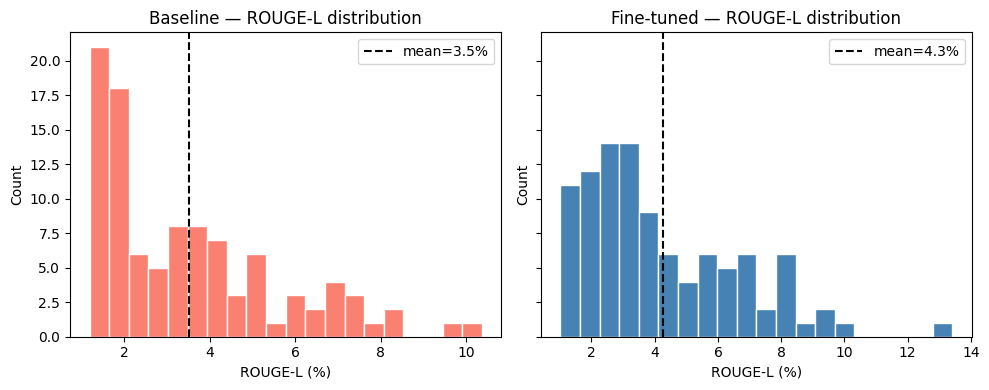

In [11]:
base_rl = [rouge_l_f1(p, r) for p, r in zip(baseline_preds, refs)]
ft_rl   = [rouge_l_f1(p, r) for p, r in zip(ft_preds,       refs)]

base_rl_mean = np.mean(base_rl) * 100
ft_rl_mean   = np.mean(ft_rl)   * 100

print(f"Baseline   ROUGE-L: {base_rl_mean:.1f}%")
print(f"Fine-tuned ROUGE-L: {ft_rl_mean:.1f}%")
print(f"Delta: {ft_rl_mean - base_rl_mean:+.1f}pp")

# Distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, scores, label, color in [
    (axes[0], base_rl, "Baseline",    "salmon"),
    (axes[1], ft_rl,   "Fine-tuned",  "steelblue"),
]:
    ax.hist([s * 100 for s in scores], bins=20, color=color, edgecolor="white")
    ax.axvline(np.mean(scores) * 100, color="black", linestyle="--", label=f"mean={np.mean(scores)*100:.1f}%")
    ax.set_title(f"{label} — ROUGE-L distribution")
    ax.set_xlabel("ROUGE-L (%)")
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.savefig("outputs_qwen35/bench_rouge_l.png", dpi=150)
plt.show()

## 7 — Benchmark 4: Inference Latency (tokens/sec)

Baseline   avg tokens/sec: 22.0
Fine-tuned avg tokens/sec: 17.8
Delta: -4.2 tok/s


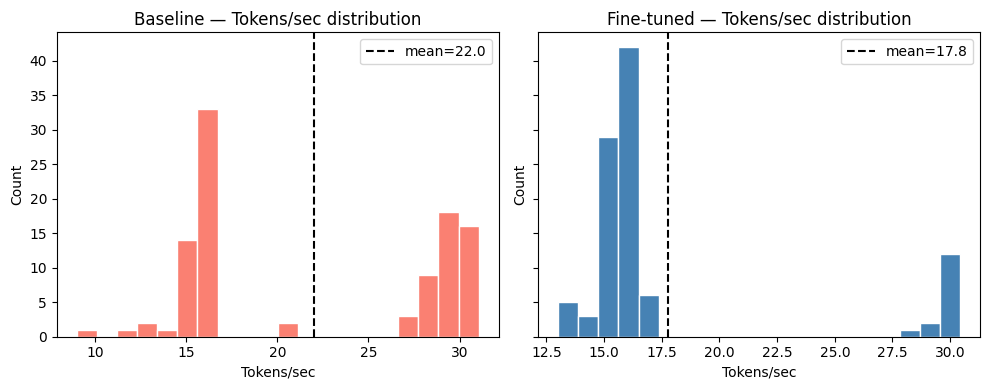

In [12]:
base_tps_mean = np.mean(baseline_tps)
ft_tps_mean   = np.mean(ft_tps)

print(f"Baseline   avg tokens/sec: {base_tps_mean:.1f}")
print(f"Fine-tuned avg tokens/sec: {ft_tps_mean:.1f}")
print(f"Delta: {ft_tps_mean - base_tps_mean:+.1f} tok/s")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, tps, label, color in [
    (axes[0], baseline_tps, "Baseline",   "salmon"),
    (axes[1], ft_tps,       "Fine-tuned", "steelblue"),
]:
    ax.hist(tps, bins=20, color=color, edgecolor="white")
    ax.axvline(np.mean(tps), color="black", linestyle="--", label=f"mean={np.mean(tps):.1f}")
    ax.set_title(f"{label} — Tokens/sec distribution")
    ax.set_xlabel("Tokens/sec")
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.savefig("outputs_qwen35/bench_latency.png", dpi=150)
plt.show()

## 8 — Summary: All Metrics Side-by-Side

Metric                         Baseline   Fine-tuned    Delta
--------------------------------------------------------------
json_parse_rate (%)                0.0%        0.0%     +0.0
location_accuracy (%)             26.0%       26.0%     +0.0
rouge_l (%)                        3.5%        4.3%     +0.7
avg_tokens_per_sec                22.0 tok/s       17.8 tok/s     -4.2


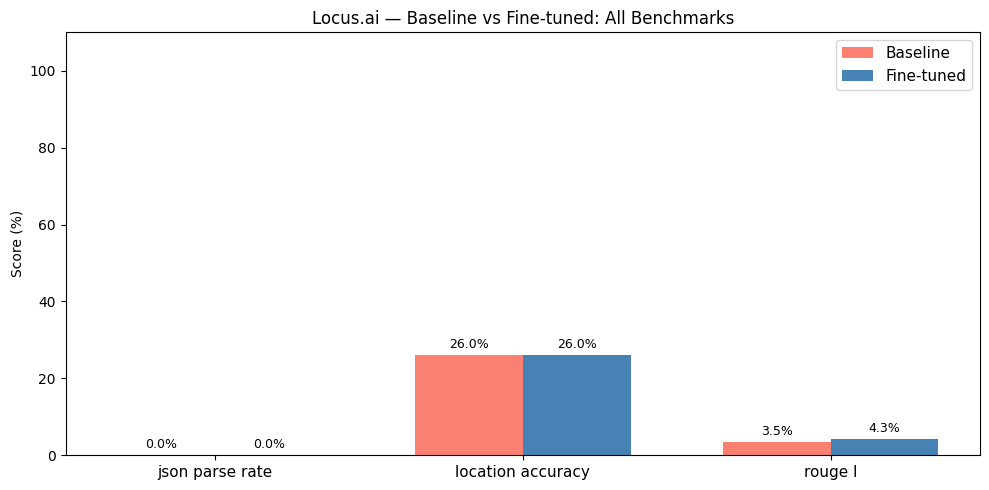


Saved: outputs_qwen35/benchmark_summary.png


In [13]:
base_metrics = compute_metrics(baseline_preds, refs, baseline_tps)
ft_metrics   = compute_metrics(ft_preds,       refs, ft_tps)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'Metric':<28} {'Baseline':>10} {'Fine-tuned':>12} {'Delta':>8}")
print("-" * 62)
for k in base_metrics:
    b, f = base_metrics[k], ft_metrics[k]
    unit = " tok/s" if "tok" in k else "%"
    print(f"{k:<28} {b:>9.1f}{unit}  {f:>9.1f}{unit}  {f-b:>+7.1f}")

# ── Bar chart for % metrics ───────────────────────────────────────────────────
pct_keys   = [k for k in base_metrics if "%" in k]
labels     = [k.replace(" (%)", "").replace("_", " ") for k in pct_keys]
base_vals  = [base_metrics[k] for k in pct_keys]
ft_vals    = [ft_metrics[k]   for k in pct_keys]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars_b = ax.bar(x - w/2, base_vals, w, label="Baseline",    color="salmon")
bars_f = ax.bar(x + w/2, ft_vals,   w, label="Fine-tuned",  color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Score (%)")
ax.set_title("Locus.ai — Baseline vs Fine-tuned: All Benchmarks")
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
for bar in list(bars_b) + list(bars_f):
    ax.annotate(f"{bar.get_height():.1f}%",
                (bar.get_x() + bar.get_width() / 2, bar.get_height() + 1),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("outputs_qwen35/benchmark_summary.png", dpi=150)
plt.show()
print("\nSaved: outputs_qwen35/benchmark_summary.png")

## 9 — Qualitative Inspection: Side-by-Side Predictions

In [14]:
# ── Print N side-by-side examples ─────────────────────────────────────────────
N_SHOW = 5

for i in range(N_SHOW):
    print(f"{'='*70}")
    print(f"Example {i+1}")
    print(f"INSTRUCTION: {test_examples[i]['instruction'][:200]}")
    print(f"\nREFERENCE:   {refs[i]}")
    print(f"\nBASELINE:    {baseline_preds[i][:300]}")
    print(f"\nFINE-TUNED:  {ft_preds[i][:300]}")
    
    b_loc = extract_primary(baseline_preds[i])
    f_loc = extract_primary(ft_preds[i])
    r_loc = extract_primary(refs[i])
    print(f"\nLocation — ref: '{r_loc}'  |  baseline: '{b_loc}'  |  ft: '{f_loc}'")
    print()

Example 1
INSTRUCTION: Where in the human cell is the protein OPA1 located?

REFERENCE:   {
  "primary_location": "Mitochondria;Nucleoplasm",
  "additional_details": "OPA1 is experimentally validated at Mitochondria;Nucleoplasm via Human Protein Atlas imaging data. GO Cellular Component annotations additionally place it at: mitochondrion, membrane.",
  "expressed_tissues": [
    "adrenal gland",
    "appendix",
    "breast",
    "bronchus",
    "caudate",
    "cerebellum",
    "cervix",
    "colon",
    "duodenum",
    "endometrium 1",
    "endometrium 2",
    "epididymis",
    "esophagus",
    "fallopian tube",
    "gallbladder",
    "heart muscle",
    "hippocampus",
    "kidney",
    "liver",
    "lung",
    "lymph node",
    "nasopharynx",
    "ovary",
    "pancreas",
    "parathyroid gland",
    "placenta",
    "rectum",
    "seminal vesicle",
    "skin 1",
    "skin 2",
    "small intestine",
    "smooth muscle",
    "soft tissue 1",
    "spleen",
    "stomach 1",
    "stomach 2"